# Modelo Base (*baseline*) — predicción de enfermedad cardíaca
## Dataset `corazon.csv`

---

### Qué es un modelo base y por qué se construye primero

Un **modelo base** es el modelo más simple que resuelve el problema de forma
razonable. No pretende ser bueno: pretende ser **la vara de medir**.

Sin él, una exactitud del 85 % no significa nada. ¿Es buena? Depende de con qué se
compare:

* Si predecir siempre *"sano"* ya acierta el 52 %, un modelo del 85 % aporta
  33 puntos de valor real.
* Si una sola regla clínica escrita en una línea acierta el 82 %, ese mismo modelo
  del 85 % aporta 3 puntos — y hay que preguntarse si justifican el coste de
  entrenarlo, mantenerlo, explicarlo ante un comité clínico y monitorizarlo en
  producción.

**Los dos escenarios son indistinguibles sin un modelo base.** Por eso se construye
*antes* de entrenar cualquier modelo de machine learning, no después.

El modelo base de este notebook es un **modelo de heurísticas**: reglas explícitas
derivadas de una única variable clínica, sin ningún parámetro aprendido.

### Contenido

| Sección | Contenido |
|---|---|
| 1 | Pipeline de preprocesamiento reutilizado de la tarea anterior |
| 2 | División Train / Test |
| 3 | Elección y justificación de las métricas de evaluación |
| 4 | **Selección de la variable más importante** y su justificación |
| 5 | Definición de los modelos base (aleatorio, heurístico, aprendido) |
| 6 | **Validación cruzada**: media y desviación estándar de cada métrica |
| 7 | Evaluación en el conjunto de prueba |
| 8 | **Curvas de aprendizaje** y **gráficas de escalabilidad** (tiempo vs. score) |
| 9 | Interpretación de los resultados |
| 10 | Análisis de los resultados |
| 11 | Conclusiones |
| 12 | Recomendaciones para construir el modelo de machine learning |
| 13 | Propuestas e ideas |
| 14 | Persistencia del modelo base y de la tabla de referencia |

In [1]:
import time
import warnings

import joblib
import matplotlib as mpl
import matplotlib.pyplot as plt
import numpy as np
import pandas as pd
import sklearn
from sklearn.base import BaseEstimator, ClassifierMixin, TransformerMixin, clone
from sklearn.compose import ColumnTransformer
from sklearn.dummy import DummyClassifier
from sklearn.feature_selection import SelectKBest, VarianceThreshold, mutual_info_classif
from sklearn.impute import SimpleImputer
from sklearn.linear_model import LogisticRegression
from sklearn.metrics import (
    accuracy_score,
    average_precision_score,
    balanced_accuracy_score,
    confusion_matrix,
    f1_score,
    make_scorer,
    precision_recall_curve,
    precision_score,
    recall_score,
    roc_auc_score,
    roc_curve,
)
from sklearn.model_selection import (
    StratifiedKFold,
    cross_validate,
    learning_curve,
    train_test_split,
)
from sklearn.pipeline import Pipeline
from sklearn.preprocessing import (
    FunctionTransformer,
    KBinsDiscretizer,
    MinMaxScaler,
    OneHotEncoder,
    OrdinalEncoder,
    PowerTransformer,
    StandardScaler,
)
from sklearn.tree import DecisionTreeClassifier

warnings.filterwarnings("ignore")

pd.set_option("display.max_columns", 60)
pd.set_option("display.width", 160)

RANDOM_STATE = 42
UMBRAL_DECISION = 0.5

AZUL, NARANJA, AQUA, AMARILLO = "#2a78d6", "#eb6834", "#1baf7a", "#eda100"
MAGENTA, VIOLETA = "#e87ba4", "#4a3aa7"
TINTA, TINTA2 = "#0b0b0b", "#52514e"
mpl.rcParams.update(
    {
        "figure.facecolor": "white",
        "axes.facecolor": "white",
        "axes.edgecolor": "#d8d7d2",
        "axes.grid": True,
        "grid.color": "#ebeae5",
        "grid.linewidth": 0.8,
        "axes.axisbelow": True,
        "axes.spines.top": False,
        "axes.spines.right": False,
        "text.color": TINTA,
        "axes.labelcolor": TINTA2,
        "xtick.color": TINTA2,
        "ytick.color": TINTA2,
        "axes.titlesize": 11,
        "font.size": 9,
        "figure.dpi": 110,
    }
)

print("scikit-learn:", sklearn.__version__, "| pandas:", pd.__version__, "| numpy:", np.__version__)

scikit-learn: 1.9.0 | pandas: 3.0.5 | numpy: 2.5.2


---
# 1. Pipeline de preprocesamiento reutilizado

Se reutiliza **el mismo pipeline construido en la tarea anterior**, sin cambios.
Aquí se reproduce de forma condensada para que este notebook sea autoejecutable;
la justificación detallada de cada decisión (por qué mediana y no media, por qué
recortar los atípicos en lugar de eliminarlos, por qué *one-hot* para las nominales
y *ordinal* para las ordinales) está documentada en el notebook de *Feature
Engineering*.

Reutilizarlo íntegro no es un detalle: **si el preprocesamiento cambiara entre el
modelo base y el modelo final, la comparación entre ambos dejaría de ser válida**,
porque no se sabría si la mejora viene del modelo o de haber preparado mejor los
datos.

In [2]:
# ---------------------------------------------------------------- catálogo del dominio
CATEGORIAS_VALIDAS = {
    "sex": ["female", "male"],
    "chest_pain": ["asymptomatic", "nonanginal", "nontypical", "typical"],
    "rest_ecg": ["left ventricular hypertrophy", "normal", "st-t wave abnormality"],
    "exang": ["0", "1"],
    "slope": ["1", "2", "3"],
    "thal": ["fixed", "normal", "reversable"],
    "disease": ["0", "1"],
}
COLS_NUM = ["age", "rest_bp", "chol", "max_hr", "old_peak", "ca", "fbs"]
OBJETIVO = "disease"


def sanear_dataset(df):
    """Convierte tipos y transforma en NaN todo valor no interpretable."""
    df = df.copy()
    for col in COLS_NUM:
        df[col] = pd.to_numeric(df[col], errors="coerce")
    for col, validas in CATEGORIAS_VALIDAS.items():
        s = df[col].astype("string").str.strip().str.lower()
        s = s.str.replace(r"\s+", " ", regex=True)
        df[col] = s.where(s.isin(validas), other=pd.NA)
    return df


def a_numerico(X):
    """Convierte todas las columnas a float; lo no convertible queda como NaN."""
    return pd.DataFrame(X).apply(pd.to_numeric, errors="coerce").astype(float)


def a_texto(X):
    """Convierte a texto normalizado usando np.nan para los faltantes."""
    df = pd.DataFrame(X).astype(object)

    def normalizar(valor):
        return np.nan if pd.isna(valor) else str(valor).strip().lower()

    aplicar = df.map if hasattr(pd.DataFrame, "map") else df.applymap
    return aplicar(normalizar)


def nombres_log(transformador, nombres):
    """Nombres de salida de la rama logarítmica."""
    return np.array([f"log_{n}" for n in nombres])


def nombres_raiz(transformador, nombres):
    """Nombres de salida de la rama de raíz cuadrada."""
    return np.array([f"sqrt_{n}" for n in nombres])


A_NUMERICO = FunctionTransformer(a_numerico, feature_names_out="one-to-one")
A_TEXTO = FunctionTransformer(a_texto, feature_names_out="one-to-one")

In [3]:
class SaneadorTipos(TransformerMixin, BaseEstimator):
    """Convierte a numérico o a categoría válida, marcando como NaN lo no interpretable."""

    def __init__(self, cols_numericas=None, categorias_validas=None):
        self.cols_numericas = cols_numericas
        self.categorias_validas = categorias_validas

    def fit(self, X, y=None):
        self.feature_names_in_ = np.asarray(X.columns)
        self.n_features_in_ = X.shape[1]
        return self

    def transform(self, X):
        X = pd.DataFrame(X).copy()
        for col in self.cols_numericas or []:
            if col in X.columns:
                X[col] = pd.to_numeric(X[col], errors="coerce")
        for col, validas in (self.categorias_validas or {}).items():
            if col in X.columns:
                s = X[col].astype("string").str.strip().str.lower()
                s = s.str.replace(r"\s+", " ", regex=True)
                X[col] = s.where(s.isin(validas), other=pd.NA)
        return X

    def get_feature_names_out(self, input_features=None):
        return np.asarray(self.feature_names_in_ if input_features is None else input_features)


class RecortadorAtipicos(TransformerMixin, BaseEstimator):
    """Winsoriza cada columna numérica a los límites de Tukey aprendidos en fit."""

    def __init__(self, factor=1.5, metodo="iqr"):
        self.factor = factor
        self.metodo = metodo

    def fit(self, X, y=None):
        X = pd.DataFrame(X)
        self.nombres_entrada_ = np.asarray(X.columns)
        self.n_features_in_ = X.shape[1]
        Xn = X.apply(pd.to_numeric, errors="coerce").astype(float)
        if self.metodo == "iqr":
            q1, q3 = Xn.quantile(0.25), Xn.quantile(0.75)
            iqr = q3 - q1
            self.limite_inferior_ = (q1 - self.factor * iqr).to_numpy(dtype=float)
            self.limite_superior_ = (q3 + self.factor * iqr).to_numpy(dtype=float)
        else:
            self.limite_inferior_ = Xn.quantile(0.01).to_numpy(dtype=float)
            self.limite_superior_ = Xn.quantile(0.99).to_numpy(dtype=float)
        return self

    def transform(self, X):
        X = pd.DataFrame(X).apply(pd.to_numeric, errors="coerce").astype(float)
        return X.clip(lower=self.limite_inferior_, upper=self.limite_superior_, axis=1)

    def get_feature_names_out(self, input_features=None):
        return np.asarray(self.nombres_entrada_ if input_features is None else input_features)


class AtributosClinicos(TransformerMixin, BaseEstimator):
    """Genera atributos derivados a partir del conocimiento del dominio clínico."""

    def __init__(self, incluir_interacciones=True):
        self.incluir_interacciones = incluir_interacciones

    def fit(self, X, y=None):
        self.nombres_entrada_ = np.asarray(pd.DataFrame(X).columns)
        self.n_features_in_ = len(self.nombres_entrada_)
        return self

    def transform(self, X):
        X = pd.DataFrame(X).copy()

        def num(columna):
            """Devuelve una columna convertida a número."""
            return pd.to_numeric(X[columna], errors="coerce")

        edad, fc_max = num("age"), num("max_hr")
        fc_teorica = 220 - edad

        nuevas = pd.DataFrame(index=X.index)
        nuevas["fc_maxima_teorica"] = fc_teorica
        nuevas["reserva_cardiaca"] = fc_max - fc_teorica
        nuevas["pct_fc_alcanzada"] = fc_max / fc_teorica.replace(0, np.nan)

        if self.incluir_interacciones:
            nuevas["ratio_chol_edad"] = num("chol") / edad.replace(0, np.nan)
            nuevas["presion_x_chol"] = num("rest_bp") * num("chol") / 1000.0
            nuevas["indice_riesgo_st"] = num("old_peak") * (num("slope") - 1)

        return nuevas.to_numpy(dtype=float)

    def get_feature_names_out(self, input_features=None):
        base = ["fc_maxima_teorica", "reserva_cardiaca", "pct_fc_alcanzada"]
        if self.incluir_interacciones:
            base += ["ratio_chol_edad", "presion_x_chol", "indice_riesgo_st"]
        return np.asarray(base)

In [4]:
# ---------------------------------------------------------------- grupos de columnas
CONTINUAS = ["age", "rest_bp", "chol", "max_hr", "old_peak"]
ASIMETRICAS = ["chol", "old_peak"]
DISCRETIZAR = ["age", "chol", "max_hr"]
CONTEO = ["ca"]
BINARIAS = ["sex", "exang", "fbs"]
ORDINALES = ["slope"]
NOMINALES = ["chest_pain", "rest_ecg", "thal"]
DERIVADAS_IN = ["age", "max_hr", "chol", "rest_bp", "old_peak", "slope"]


def construir_preprocesador():
    """Devuelve el ColumnTransformer con una rama por tipo de dato."""
    rama_continuas = Pipeline(
        [
            ("atipicos", RecortadorAtipicos(factor=1.5, metodo="iqr")),
            ("imputador", SimpleImputer(strategy="median", add_indicator=True)),
            ("potencia", PowerTransformer(method="yeo-johnson", standardize=False)),
            ("escalador", StandardScaler()),
        ]
    )
    rama_log = Pipeline(
        [
            ("numerico", clone(A_NUMERICO)),
            ("imputador", SimpleImputer(strategy="median")),
            ("log", FunctionTransformer(np.log1p, validate=True, feature_names_out=nombres_log)),
            ("escalador", StandardScaler()),
        ]
    )
    rama_raiz = Pipeline(
        [
            ("numerico", clone(A_NUMERICO)),
            ("imputador", SimpleImputer(strategy="median")),
            ("raiz", FunctionTransformer(np.sqrt, validate=True, feature_names_out=nombres_raiz)),
            ("escalador", StandardScaler()),
        ]
    )
    rama_discretizacion = Pipeline(
        [
            ("numerico", clone(A_NUMERICO)),
            ("imputador", SimpleImputer(strategy="median")),
            ("intervalos", KBinsDiscretizer(n_bins=5, encode="onehot-dense", strategy="quantile")),
        ]
    )
    rama_derivadas = Pipeline(
        [
            ("generador", AtributosClinicos(incluir_interacciones=True)),
            ("imputador", SimpleImputer(strategy="median")),
            ("atipicos", RecortadorAtipicos(factor=3.0, metodo="iqr")),
            ("escalador", StandardScaler()),
        ]
    )
    rama_conteo = Pipeline(
        [
            ("numerico", clone(A_NUMERICO)),
            ("imputador", SimpleImputer(strategy="median")),
            ("escalador", MinMaxScaler()),
        ]
    )
    rama_binarias = Pipeline(
        [
            ("texto", clone(A_TEXTO)),
            ("imputador", SimpleImputer(strategy="most_frequent")),
            ("codificar", OrdinalEncoder(handle_unknown="use_encoded_value", unknown_value=-1)),
        ]
    )
    rama_ordinales = Pipeline(
        [
            ("texto", clone(A_TEXTO)),
            ("imputador", SimpleImputer(strategy="most_frequent")),
            (
                "codificar",
                OrdinalEncoder(
                    categories=[["1", "2", "3"]],
                    handle_unknown="use_encoded_value",
                    unknown_value=-1,
                ),
            ),
            ("escalador", MinMaxScaler()),
        ]
    )
    rama_nominales = Pipeline(
        [
            ("texto", clone(A_TEXTO)),
            ("imputador", SimpleImputer(strategy="most_frequent")),
            (
                "codificar",
                OneHotEncoder(
                    handle_unknown="infrequent_if_exist", min_frequency=0.01, sparse_output=False
                ),
            ),
        ]
    )
    return ColumnTransformer(
        transformers=[
            ("continuas", rama_continuas, CONTINUAS),
            ("log", rama_log, ASIMETRICAS),
            ("raiz", rama_raiz, ASIMETRICAS),
            ("discretas", rama_discretizacion, DISCRETIZAR),
            ("derivadas", rama_derivadas, DERIVADAS_IN),
            ("conteo", rama_conteo, CONTEO),
            ("binarias", rama_binarias, BINARIAS),
            ("ordinales", rama_ordinales, ORDINALES),
            ("nominales", rama_nominales, NOMINALES),
        ],
        remainder="drop",
    )


def construir_pipeline(modelo):
    """Pipeline completo: saneamiento + preprocesamiento + selección + estimador."""
    return Pipeline(
        [
            ("saneador", SaneadorTipos(COLS_NUM, CATEGORIAS_VALIDAS)),
            ("preproceso", construir_preprocesador()),
            (
                "seleccion",
                Pipeline(
                    [
                        ("umbral_varianza", VarianceThreshold(threshold=0.0)),
                        ("mejores_k", SelectKBest(score_func=mutual_info_classif, k="all")),
                    ]
                ),
            ),
            ("modelo", modelo),
        ]
    )

---
# 2. Carga de datos y división Train / Test

Se aplica el saneamiento a nivel de fila de la tarea anterior (parseo de tipos,
eliminación de duplicados y de filas sin etiqueta) y se parte con **el mismo
`random_state` y la misma estratificación** que en el notebook de Feature
Engineering.

Esto es deliberado: el conjunto de prueba debe contener exactamente los mismos
pacientes en ambas tareas. Si cambiara, la comparación entre el modelo base y el
modelo de machine learning mediría en parte la suerte de la partición, no la
calidad de los modelos.

In [6]:
crudo = pd.read_csv("/mnt/c/Users/KATANA/Heart_project/data/01_raw/corazon.csv", dtype=str)
saneado = sanear_dataset(crudo)

limpio = saneado.drop_duplicates().reset_index(drop=True)
limpio = limpio.dropna(subset=[OBJETIVO]).reset_index(drop=True)
limpio[OBJETIVO] = limpio[OBJETIVO].astype(int)
limpio = limpio.drop_duplicates().reset_index(drop=True)

X = limpio.drop(columns=[OBJETIVO])
y = limpio[OBJETIVO]

X_train, X_test, y_train, y_test = train_test_split(
    X, y, test_size=0.20, random_state=RANDOM_STATE, stratify=y
)

print(f"Archivo original      : {crudo.shape[0]:>5} filas")
print(f"Tras sanear y deduplicar: {limpio.shape[0]:>5} filas")
print()
print(f"X_train: {X_train.shape}   positivos: {y_train.mean():.1%}")
print(f"X_test : {X_test.shape}   positivos: {y_test.mean():.1%}")
print()
print("Tasa base (clase mayoritaria en train):", f"{max(y_train.mean(), 1 - y_train.mean()):.1%}")

Archivo original      :  3030 filas
Tras sanear y deduplicar:   480 filas

X_train: (384, 13)   positivos: 47.9%
X_test : (96, 13)   positivos: 47.9%

Tasa base (clase mayoritaria en train): 52.1%


---
# 3. Métricas de evaluación: elección y justificación

El problema es **clasificación binaria en un contexto de cribado diagnóstico**. La
elección de métricas no es un trámite: determina qué modelo se declarará "mejor".

### El coste de los dos errores no es el mismo

| Error | Qué significa clínicamente | Consecuencia |
|---|---|---|
| **Falso negativo** (predecir sano a un enfermo) | Un paciente con enfermedad coronaria se va a casa sin seguimiento | Riesgo de evento cardíaco no prevenido. **Potencialmente mortal** |
| **Falso positivo** (predecir enfermo a un sano) | Se deriva a pruebas adicionales a alguien sano | Coste económico, ansiedad, exposición a pruebas invasivas. **Recuperable** |

Un falso negativo es mucho más caro que un falso positivo. Eso descarta la
exactitud como métrica única: **la exactitud trata ambos errores como
equivalentes**.

### Métricas seleccionadas

| Métrica | Qué mide | Por qué se incluye |
|---|---|---|
| **Exactitud** (*accuracy*) | % de aciertos totales | Fácil de comunicar; solo es informativa porque el dataset está balanceado (48/52) |
| **Exactitud balanceada** | media de sensibilidad y especificidad | Inmune al desbalanceo; protege ante cambios de prevalencia en producción |
| **Sensibilidad** (*recall*) | % de enfermos detectados | **Métrica prioritaria**: mide directamente los falsos negativos, el error caro |
| **Precisión** | % de aciertos entre los marcados como enfermos | Controla el coste de derivar sanos a pruebas innecesarias |
| **F1** | media armónica de precisión y sensibilidad | Resumen equilibrado; **métrica principal de comparación** |
| **Especificidad** | % de sanos correctamente descartados | Complementa la sensibilidad; juntas describen el comportamiento completo |
| **ROC AUC** | capacidad de ordenar pacientes por riesgo | Independiente del umbral: separa la calidad del modelo de la elección del punto de corte |
| **PR AUC** (*average precision*) | precisión media a lo largo del recall | Más informativa que ROC AUC si la prevalencia bajara |

**Decisión:** se optimiza y compara por **F1**, se vigila la **sensibilidad** como
restricción clínica, y se reporta **ROC AUC** como medida de calidad independiente
del umbral.

In [7]:
def especificidad(y_real, y_pred):
    """Proporción de sanos correctamente identificados: VN / (VN + FP)."""
    matriz = confusion_matrix(y_real, y_pred, labels=[0, 1])
    vn, fp = matriz[0, 0], matriz[0, 1]
    return vn / (vn + fp) if (vn + fp) > 0 else 0.0


METRICAS = {
    "exactitud": "accuracy",
    "exactitud_balanceada": "balanced_accuracy",
    "sensibilidad": "recall",
    "precision": "precision",
    "f1": "f1",
    "especificidad": make_scorer(especificidad),
    "roc_auc": "roc_auc",
    "pr_auc": "average_precision",
}

print("Métricas que se calcularán en cada partición de la validación cruzada:")
for nombre in METRICAS:
    print("  -", nombre)

Métricas que se calcularán en cada partición de la validación cruzada:
  - exactitud
  - exactitud_balanceada
  - sensibilidad
  - precision
  - f1
  - especificidad
  - roc_auc
  - pr_auc


---
# 4. Selección de la variable más importante

El modelo base heurístico se construirá sobre **una sola variable**. Elegirla "a
ojo" no es aceptable: se seleccionó comparando las 13 variables con **cuatro
criterios independientes**, y luego contrastando el resultado con el conocimiento
clínico.

### Los cuatro criterios

1. **Información mutua** — cuánta información sobre el diagnóstico aporta la
   variable. Captura relaciones no lineales, a diferencia de la correlación.
2. **ROC AUC univariante validado** — capacidad de ordenar pacientes por riesgo
   usando solo esa variable.
3. **F1 y exactitud de un *decision stump*** — un árbol de profundidad 1 entrenado
   solo con esa variable: literalmente la mejor regla de una condición que se puede
   escribir con ella.
4. **Plausibilidad clínica** — que la variable tenga un mecanismo fisiológico
   conocido, no una asociación espuria.

**Todos los criterios se calculan con validación cruzada sobre el conjunto de
entrenamiento**, con la imputación y la codificación dentro del pipeline. Calcular
la codificación de una categórica usando la variable objetivo de todo el dataset
sería fuga de información y produciría un ranking falsamente optimista.

In [8]:
def pipeline_univariante(columna, X_ref):
    """Pipeline mínimo (imputar + codificar + regla de un nivel) para una sola variable."""
    valores_numericos = pd.to_numeric(X_ref[columna], errors="coerce")
    es_numerica = valores_numericos.notna().sum() > 0.5 * len(X_ref)

    if es_numerica:
        pasos = [
            ("numerico", clone(A_NUMERICO)),
            ("imputador", SimpleImputer(strategy="median")),
        ]
    else:
        pasos = [
            ("texto", clone(A_TEXTO)),
            ("imputador", SimpleImputer(strategy="most_frequent")),
            ("codificar", OneHotEncoder(handle_unknown="ignore", sparse_output=False)),
        ]
    pasos.append(("regla", DecisionTreeClassifier(max_depth=1, random_state=RANDOM_STATE)))
    return Pipeline(pasos), "numérica" if es_numerica else "categórica"


cv_ranking = StratifiedKFold(n_splits=5, shuffle=True, random_state=RANDOM_STATE)
filas_ranking = []

for columna in X_train.columns:
    pipe, tipo = pipeline_univariante(columna, X_train)
    resultado = cross_validate(
        pipe,
        X_train[[columna]],
        y_train,
        cv=cv_ranking,
        scoring=["accuracy", "f1", "roc_auc", "recall"],
    )
    filas_ranking.append(
        {
            "variable": columna,
            "tipo": tipo,
            "auc_univariante": resultado["test_roc_auc"].mean(),
            "f1_regla": resultado["test_f1"].mean(),
            "exactitud_regla": resultado["test_accuracy"].mean(),
            "sensibilidad_regla": resultado["test_recall"].mean(),
        }
    )

ranking = (
    pd.DataFrame(filas_ranking)
    .sort_values("auc_univariante", ascending=False)
    .reset_index(drop=True)
)
ranking.round(3)

,variable,tipo,auc_univariante,f1_regla,exactitud_regla,sensibilidad_regla
0,thal,categórica,0.748,0.724,0.750,0.690
1,ca,numérica,0.727,0.684,0.732,0.608
2,chest_pain,categórica,0.727,0.732,0.724,0.788
3,slope,numérica,0.689,0.692,0.687,0.733
4,exang,numérica,0.673,0.574,0.682,0.462
5,old_peak,numérica,0.660,0.566,0.667,0.499
6,age,numérica,0.625,0.593,0.628,0.576
7,max_hr,numérica,0.621,0.603,0.620,0.621
8,sex,categórica,0.608,0.661,0.599,0.821
9,rest_ecg,categórica,0.551,0.556,0.549,0.587


In [9]:
# Información mutua como cuarto criterio, calculada sobre los datos ya preprocesados
prep = construir_pipeline(DummyClassifier())
prep_sin_modelo = Pipeline(prep.steps[:2])
X_train_prep = prep_sin_modelo.fit_transform(X_train, y_train)
nombres_prep = prep_sin_modelo.named_steps["preproceso"].get_feature_names_out()

info_mutua = pd.Series(
    mutual_info_classif(X_train_prep, y_train, random_state=RANDOM_STATE), index=nombres_prep
)


# Se agrega al nivel de la variable original: cada rama del ColumnTransformer
# puede haber generado varias columnas a partir de la misma variable de entrada.
def variable_origen(nombre_columna):
    """Recupera el nombre de la variable original a partir del atributo generado."""
    cuerpo = nombre_columna.split("__", 1)[1]
    for var in X_train.columns:
        if (
            cuerpo.startswith(var)
            or cuerpo.startswith(f"log_{var}")
            or cuerpo.startswith(f"sqrt_{var}")
        ):
            return var
    return None


origenes = pd.Series([variable_origen(n) for n in nombres_prep], index=nombres_prep)
mi_por_variable = info_mutua.groupby(origenes).max().sort_values(ascending=False)

ranking["info_mutua"] = ranking["variable"].map(mi_por_variable)
ranking.sort_values("auc_univariante", ascending=False).round(3)

,variable,tipo,auc_univariante,f1_regla,exactitud_regla,sensibilidad_regla,info_mutua
0,thal,categórica,0.748,0.724,0.750,0.690,0.175
1,ca,numérica,0.727,0.684,0.732,0.608,0.107
2,chest_pain,categórica,0.727,0.732,0.724,0.788,0.119
3,slope,numérica,0.689,0.692,0.687,0.733,0.038
4,exang,numérica,0.673,0.574,0.682,0.462,0.080
5,old_peak,numérica,0.660,0.566,0.667,0.499,0.084
6,age,numérica,0.625,0.593,0.628,0.576,0.041
7,max_hr,numérica,0.621,0.603,0.620,0.621,0.107
8,sex,categórica,0.608,0.661,0.599,0.821,0.019
9,rest_ecg,categórica,0.551,0.556,0.549,0.587,0.076


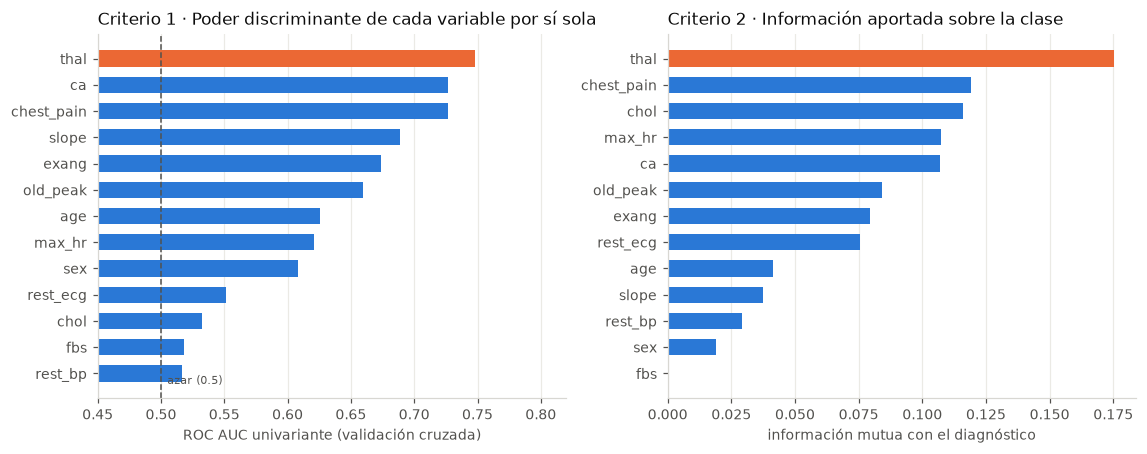

In [10]:
fig, axes = plt.subplots(1, 2, figsize=(10.5, 4.2))

orden = ranking.sort_values("auc_univariante")
colores = [AZUL if v != orden["variable"].iloc[-1] else NARANJA for v in orden["variable"]]

axes[0].barh(orden["variable"], orden["auc_univariante"], color=colores, height=0.62)
axes[0].axvline(0.5, color=TINTA2, linestyle="--", linewidth=1)
axes[0].text(0.505, -0.4, "azar (0.5)", fontsize=7.5, color=TINTA2)
axes[0].set_xlim(0.45, 0.82)
axes[0].set_xlabel("ROC AUC univariante (validación cruzada)")
axes[0].set_title("Criterio 1 · Poder discriminante de cada variable por sí sola", loc="left")
axes[0].grid(axis="y", visible=False)

orden_mi = ranking.dropna(subset=["info_mutua"]).sort_values("info_mutua")
colores_mi = [AZUL if v != orden["variable"].iloc[-1] else NARANJA for v in orden_mi["variable"]]
axes[1].barh(orden_mi["variable"], orden_mi["info_mutua"], color=colores_mi, height=0.62)
axes[1].set_xlabel("información mutua con el diagnóstico")
axes[1].set_title("Criterio 2 · Información aportada sobre la clase", loc="left")
axes[1].grid(axis="y", visible=False)

plt.tight_layout()
plt.show()

In [11]:
VARIABLE_BASE = ranking.loc[ranking["auc_univariante"].idxmax(), "variable"]
print("Variable seleccionada para el modelo base:", VARIABLE_BASE)
print()

# Comportamiento de la variable elegida frente al diagnóstico
valores_base = X_train[VARIABLE_BASE].astype(object)
valores_base = valores_base.where(valores_base.notna(), "(sin dato)")

tabla = pd.crosstab(valores_base, y_train).rename(columns={0: "sanos", 1: "enfermos"})
tabla.index.name = VARIABLE_BASE
tabla["n"] = tabla.sum(axis=1)
tabla["tasa_enfermedad"] = (tabla["enfermos"] / tabla["n"]).round(3)
tabla.sort_values("tasa_enfermedad", ascending=False)

Variable seleccionada para el modelo base: thal



disease,sanos,enfermos,n,tasa_enfermedad
thal,,,,
reversable,32,112,144,0.778
fixed,7,15,22,0.682
(sin dato),13,10,23,0.435
normal,148,47,195,0.241


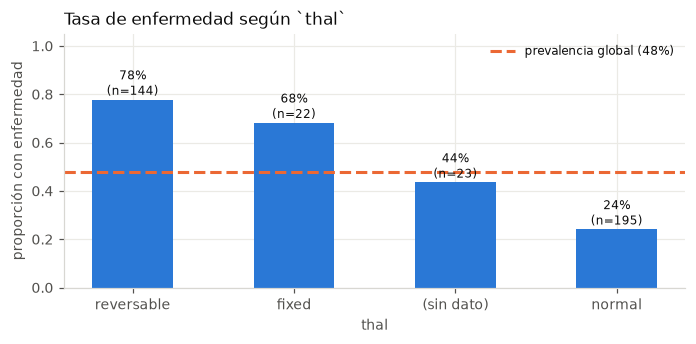

In [12]:
fig, ax = plt.subplots(figsize=(6.4, 3.2))

t = tabla.sort_values("tasa_enfermedad", ascending=False)
barras = ax.bar(list(t.index), t["tasa_enfermedad"], color=AZUL, width=0.5)
for b, (valor, n) in zip(barras, zip(t["tasa_enfermedad"], t["n"], strict=True), strict=True):
    ax.text(
        b.get_x() + b.get_width() / 2,
        valor + 0.02,
        f"{valor:.0%}\n(n={n})",
        ha="center",
        fontsize=8,
        color=TINTA,
    )
ax.axhline(
    y_train.mean(),
    color=NARANJA,
    linestyle="--",
    linewidth=2,
    label=f"prevalencia global ({y_train.mean():.0%})",
)
ax.set_ylim(0, 1.05)
ax.set_ylabel("proporción con enfermedad")
ax.set_xlabel(VARIABLE_BASE)
ax.set_title(f"Tasa de enfermedad según `{VARIABLE_BASE}`", loc="left")
ax.legend(frameon=False, fontsize=8)
plt.tight_layout()
plt.show()

### Justificación de la variable seleccionada: `thal`

`thal` es el resultado de una **gammagrafía de perfusión miocárdica con talio**, y
sus tres categorías describen el estado de la irrigación del músculo cardíaco:

| Categoría | Significado clínico | Tasa de enfermedad observada |
|---|---|---|
| `normal` | Perfusión normal en reposo y en esfuerzo | 24 % |
| `fixed` | Defecto fijo: zona sin captación en reposo y en esfuerzo → tejido infartado | 68 % |
| `reversable` | Defecto reversible: capta en reposo pero no en esfuerzo → **isquemia activa** | 78 % |

**Por qué se selecciona:**

1. **Gana en tres de los cuatro criterios cuantitativos**: el mayor ROC AUC
   univariante, la mayor exactitud de una regla de un nivel y una de las
   informaciones mutuas más altas. `chest_pain` queda muy cerca y `ca` la sigue.
2. **Su relación con la clase es directa y monótona en el sentido clínico
   correcto**: perfusión normal → riesgo bajo; cualquier defecto de perfusión →
   riesgo alto. No es una asociación estadística sin explicación.
3. **Produce una regla de decisión trivial de expresar**: `thal != normal`. Un
   modelo base debe ser explicable en una frase ante un clínico, y esta lo es.
4. **Mecanismo fisiológico establecido**: un defecto de perfusión *es* la
   manifestación de la enfermedad coronaria que se quiere detectar, no un
   correlato lejano.

**Advertencia metodológica que conviene dejar registrada:** `thal` procede de una
prueba de imagen que ya es en sí misma diagnóstica. Si el objetivo del proyecto
fuera *evitar* pruebas costosas, incluirla sería casi una fuga de información: se
estaría prediciendo la enfermedad con una prueba que se realiza precisamente para
diagnosticarla. Para un cribado previo a la gammagrafía, la variable a usar sería
`chest_pain` (AUC 0.73, y la mejor sensibilidad entre las variables con poder
discriminante alto: 0.79), que es información de anamnesis y no cuesta nada
obtener.

---
# 5. Definición de los modelos base

Se construyen **tres niveles de referencia**, no uno solo. Un único baseline dice
poco; tres niveles delimitan el terreno donde el modelo de machine learning tiene
que demostrar su valor.

| Nivel | Modelo | Qué representa |
|---|---|---|
| **0** | `DummyClassifier` (mayoritaria y estratificada) | El **piso absoluto**. Cualquier modelo que no lo supere está roto |
| **1** | **Heurística de una variable** sobre `thal` | El **modelo base oficial**: una regla clínica sin parámetros aprendidos |
| **1b** | Heurística clínica de 4 señales | Cuánto se consigue con reglas simples acumuladas, sin aprendizaje |
| **2** | *Decision stump* sobre el pipeline completo | La mejor regla única que el algoritmo puede **aprender** de los 50 atributos |

El nivel 1b es el más exigente y el más honesto: si un modelo complejo no lo supera
con claridad, no está aportando nada que no se consiga con cuatro condiciones
escritas a mano.

In [13]:
class HeuristicaUnaVariable(ClassifierMixin, BaseEstimator):
    """Modelo base: clasifica según una sola variable categórica.

    Predice la clase positiva cuando el valor de `columna` NO está en
    `categorias_negativas`. No aprende ningún parámetro de los datos: `fit` solo
    registra las clases, de modo que el modelo es idéntico antes y después de
    entrenar. Esa es exactamente la propiedad que se quiere en un modelo base.

    Parámetros
    ----------
    columna : str
        Nombre de la variable sobre la que se aplica la regla.
    categorias_negativas : tuple[str, ...]
        Valores que se consideran indicativos de ausencia de enfermedad.
    """

    def __init__(self, columna="thal", categorias_negativas=("normal",)):
        self.columna = columna
        self.categorias_negativas = categorias_negativas

    def fit(self, X, y=None):
        self.classes_ = np.array([0, 1])
        self.n_features_in_ = pd.DataFrame(X).shape[1]
        return self

    def _puntuar(self, X):
        """Devuelve la probabilidad asignada a la clase positiva."""
        valores = pd.DataFrame(X)[self.columna]
        texto = valores.astype(object).map(
            lambda v: np.nan if pd.isna(v) else str(v).strip().lower()
        )
        # Un valor ausente no aporta evidencia: se le asigna la prevalencia (0.5)
        return np.where(
            texto.isna(), UMBRAL_DECISION, np.where(texto.isin(self.categorias_negativas), 0.0, 1.0)
        ).astype(float)

    def predict(self, X):
        return (self._puntuar(X) >= UMBRAL_DECISION).astype(int)

    def predict_proba(self, X):
        p = self._puntuar(X)
        return np.column_stack([1 - p, p])

In [14]:
class HeuristicaClinica(ClassifierMixin, BaseEstimator):
    """Modelo base de reglas acumuladas: cuenta señales clínicas de riesgo.

    Cada una de las cuatro condiciones aporta un punto; se predice enfermedad
    cuando se acumulan al menos `minimo_senales` puntos. Las cuatro condiciones
    provienen de las variables mejor situadas en el ranking univariante y todas
    tienen lectura clínica directa.
    """

    SENALES = 4

    def __init__(self, minimo_senales=2):
        self.minimo_senales = minimo_senales

    def fit(self, X, y=None):
        self.classes_ = np.array([0, 1])
        self.n_features_in_ = pd.DataFrame(X).shape[1]
        return self

    def _contar_senales(self, X):
        """Suma las condiciones de riesgo presentes en cada paciente."""
        X = pd.DataFrame(X)
        texto = a_texto(X[["thal", "chest_pain"]])
        vasos = pd.to_numeric(X["ca"], errors="coerce").fillna(0)
        angina = pd.to_numeric(X["exang"], errors="coerce").fillna(0)

        defecto_perfusion = (texto["thal"].notna() & (texto["thal"] != "normal")).astype(int)
        dolor_asintomatico = (texto["chest_pain"] == "asymptomatic").astype(int)
        vasos_afectados = (vasos >= 1).astype(int)
        angina_esfuerzo = (angina == 1).astype(int)

        return (
            defecto_perfusion + dolor_asintomatico + vasos_afectados + angina_esfuerzo
        ).to_numpy(dtype=float)

    def predict(self, X):
        return (self._contar_senales(X) >= self.minimo_senales).astype(int)

    def predict_proba(self, X):
        p = self._contar_senales(X) / self.SENALES
        return np.column_stack([1 - p, p])


print("Regla del modelo base nivel 1:")
print("    thal != 'normal'  ->  enfermedad")
print()
print("Reglas del modelo base nivel 1b (>= 2 señales de 4):")
print("    1. thal != 'normal'          (defecto de perfusión miocárdica)")
print("    2. chest_pain == 'asymptomatic'  (angina silente)")
print("    3. ca >= 1                   (al menos un vaso principal afectado)")
print("    4. exang == 1                (angina inducida por el ejercicio)")

Regla del modelo base nivel 1:
    thal != 'normal'  ->  enfermedad

Reglas del modelo base nivel 1b (>= 2 señales de 4):
    1. thal != 'normal'          (defecto de perfusión miocárdica)
    2. chest_pain == 'asymptomatic'  (angina silente)
    3. ca >= 1                   (al menos un vaso principal afectado)
    4. exang == 1                (angina inducida por el ejercicio)


In [15]:
modelos_base = {
    "N0 · Siempre la clase mayoritaria": construir_pipeline(
        DummyClassifier(strategy="most_frequent")
    ),
    "N0 · Aleatorio estratificado": construir_pipeline(
        DummyClassifier(strategy="stratified", random_state=RANDOM_STATE)
    ),
    "N1 · Heurística 1 variable (thal)": Pipeline(
        [
            ("saneador", SaneadorTipos(COLS_NUM, CATEGORIAS_VALIDAS)),
            ("modelo", HeuristicaUnaVariable(columna=VARIABLE_BASE)),
        ]
    ),
    "N1b · Heurística clínica (4 señales)": Pipeline(
        [
            ("saneador", SaneadorTipos(COLS_NUM, CATEGORIAS_VALIDAS)),
            ("modelo", HeuristicaClinica(minimo_senales=2)),
        ]
    ),
    "N2 · Regla aprendida (stump)": construir_pipeline(
        DecisionTreeClassifier(max_depth=1, random_state=RANDOM_STATE)
    ),
}

ETIQUETAS_CORTAS = {
    "N0 · Siempre la clase mayoritaria": "N0 mayoritaria",
    "N0 · Aleatorio estratificado": "N0 aleatorio",
    "N1 · Heurística 1 variable (thal)": "N1 thal",
    "N1b · Heurística clínica (4 señales)": "N1b 4 reglas",
    "N2 · Regla aprendida (stump)": "N2 stump",
}

for nombre in modelos_base:
    print("·", nombre)

· N0 · Siempre la clase mayoritaria
· N0 · Aleatorio estratificado
· N1 · Heurística 1 variable (thal)
· N1b · Heurística clínica (4 señales)
· N2 · Regla aprendida (stump)


---
# 6. Validación cruzada: media y desviación estándar

Una única partición train/test da **un** número, y ese número depende de qué
pacientes cayeron en cada lado. Con 384 filas de entrenamiento, esa lotería puede
mover la exactitud varios puntos.

La validación cruzada estratificada de 10 particiones entrena y evalúa 10 veces
sobre divisiones distintas, y devuelve **una media y una desviación estándar**. La
desviación estándar es tan importante como la media: indica cuánta confianza
merece la comparación entre dos modelos.

> **Regla práctica de lectura:** si la diferencia entre las medias de dos modelos es
> menor que sus desviaciones estándar, esa diferencia **no es evidencia de que uno
> sea mejor**.

In [16]:
cv = StratifiedKFold(n_splits=10, shuffle=True, random_state=RANDOM_STATE)

filas_cv = []
detalle_cv = {}

for nombre, modelo in modelos_base.items():
    resultado = cross_validate(
        modelo, X_train, y_train, cv=cv, scoring=METRICAS, return_train_score=False, n_jobs=-1
    )
    detalle_cv[nombre] = resultado
    fila = {"modelo": nombre}
    for metrica in METRICAS:
        valores = resultado[f"test_{metrica}"]
        fila[metrica] = valores.mean()
        fila[f"{metrica}_std"] = valores.std()
    fila["tiempo_fit_s"] = resultado["fit_time"].mean()
    filas_cv.append(fila)

resultados_cv = pd.DataFrame(filas_cv).set_index("modelo")

# Tabla legible: media ± desviación estándar
tabla_legible = pd.DataFrame(
    {
        m: resultados_cv.apply(lambda r, m=m: f"{r[m]:.3f} ± {r[m + '_std']:.3f}", axis=1)
        for m in METRICAS
    }
)
tabla_legible

,exactitud,exactitud_balanceada,sensibilidad,precision,f1,especificidad,roc_auc,pr_auc
modelo,,,,,,,,
N0 · Siempre la clase mayoritaria,0.521 ± 0.007,0.500 ± 0.000,0.000 ± 0.000,0.000 ± 0.000,0.000 ± 0.000,1.000 ± 0.000,0.500 ± 0.000,0.479 ± 0.007
N0 · Aleatorio estratificado,0.552 ± 0.055,0.549 ± 0.055,0.479 ± 0.054,0.537 ± 0.061,0.506 ± 0.058,0.620 ± 0.056,0.549 ± 0.055,0.510 ± 0.030
N1 · Heurística 1 variable (thal),0.742 ± 0.036,0.743 ± 0.037,0.745 ± 0.078,0.726 ± 0.032,0.733 ± 0.044,0.740 ± 0.049,0.762 ± 0.045,0.693 ± 0.049
N1b · Heurística clínica (4 señales),0.820 ± 0.048,0.818 ± 0.050,0.761 ± 0.107,0.855 ± 0.063,0.799 ± 0.063,0.875 ± 0.072,0.865 ± 0.039,0.843 ± 0.038
N2 · Regla aprendida (stump),0.750 ± 0.049,0.748 ± 0.050,0.691 ± 0.102,0.766 ± 0.044,0.723 ± 0.068,0.805 ± 0.047,0.748 ± 0.050,0.679 ± 0.049


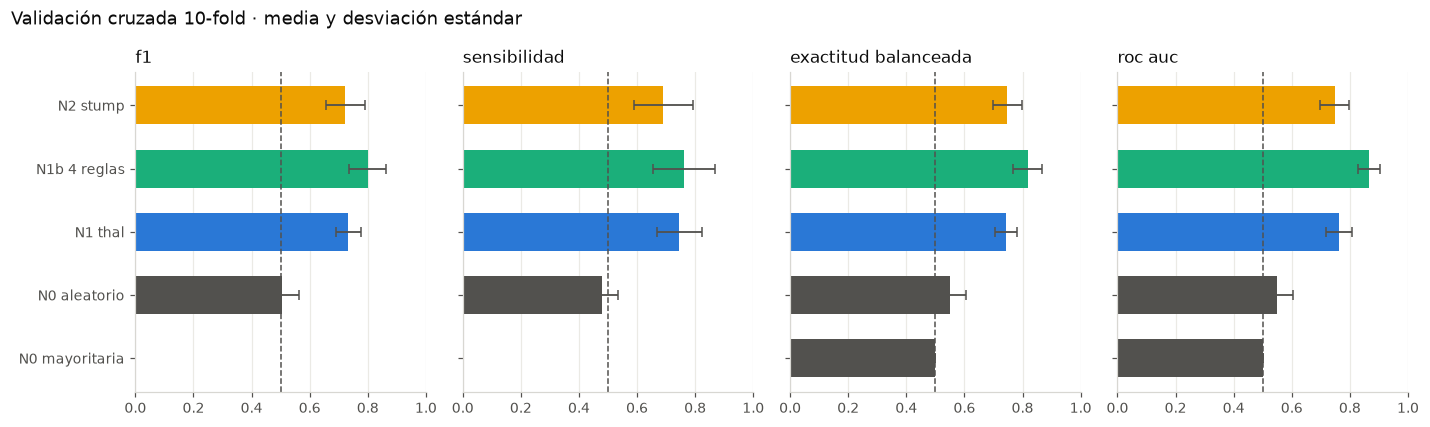

In [17]:
# Métricas principales con su dispersión
metricas_grafico = ["f1", "sensibilidad", "exactitud_balanceada", "roc_auc"]
colores_modelo = [TINTA2, TINTA2, AZUL, AQUA, AMARILLO]

fig, axes = plt.subplots(1, 4, figsize=(13, 3.9), sharey=True)
for ax, metrica in zip(axes, metricas_grafico, strict=True):
    valores = resultados_cv[metrica]
    errores = resultados_cv[f"{metrica}_std"]
    posiciones = np.arange(len(valores))
    ax.barh(
        posiciones,
        valores.to_numpy(),
        xerr=errores.to_numpy(),
        color=colores_modelo,
        height=0.6,
        error_kw={"ecolor": TINTA2, "elinewidth": 1.2, "capsize": 3},
    )
    ax.axvline(0.5, color=TINTA2, linestyle="--", linewidth=1)
    ax.set_yticks(posiciones)
    ax.set_yticklabels([ETIQUETAS_CORTAS[n] for n in valores.index])
    ax.set_xlim(0, 1.0)
    ax.set_title(metrica.replace("_", " "), loc="left")
    ax.grid(axis="y", visible=False)

fig.suptitle(
    "Validación cruzada 10-fold · media y desviación estándar",
    x=0.005,
    ha="left",
    fontsize=11.5,
)
plt.tight_layout()
plt.show()

In [18]:
# ¿Las diferencias entre modelos son mayores que su propia variabilidad?
orden_f1 = resultados_cv["f1"].sort_values(ascending=False)
print("Comparación por F1 (media ± desviación estándar):\n")
for nombre, valor in orden_f1.items():
    desv = resultados_cv.loc[nombre, "f1_std"]
    print(f"  {nombre:<42} {valor:.3f} ± {desv:.3f}")

mejor, segundo = orden_f1.index[0], orden_f1.index[1]
diferencia = orden_f1.iloc[0] - orden_f1.iloc[1]
desv_conjunta = np.sqrt(
    resultados_cv.loc[mejor, "f1_std"] ** 2 + resultados_cv.loc[segundo, "f1_std"] ** 2
)
print(f"\nDiferencia entre los dos mejores: {diferencia:.3f}")
print(f"Desviación estándar conjunta    : {desv_conjunta:.3f}")
print(
    "\nConclusión:",
    "la diferencia SUPERA la variabilidad -> es una mejora real"
    if diferencia > desv_conjunta
    else "la diferencia NO supera la variabilidad -> los modelos son equivalentes",
)

Comparación por F1 (media ± desviación estándar):

  N1b · Heurística clínica (4 señales)       0.799 ± 0.063
  N1 · Heurística 1 variable (thal)          0.733 ± 0.044
  N2 · Regla aprendida (stump)               0.723 ± 0.068
  N0 · Aleatorio estratificado               0.506 ± 0.058
  N0 · Siempre la clase mayoritaria          0.000 ± 0.000

Diferencia entre los dos mejores: 0.066
Desviación estándar conjunta    : 0.077

Conclusión: la diferencia NO supera la variabilidad -> los modelos son equivalentes


---
# 7. Evaluación en el conjunto de prueba

El conjunto de prueba se ha mantenido intacto hasta aquí. Se evalúa **una sola
vez**, sobre el modelo base oficial (nivel 1) y sobre la heurística de cuatro
señales (nivel 1b), para fijar los números que servirán de referencia.

In [19]:
MODELO_BASE_OFICIAL = "N1 · Heurística 1 variable (thal)"
MODELO_BASE_EXIGENTE = "N1b · Heurística clínica (4 señales)"

filas_test = []
predicciones = {}

for nombre, modelo in modelos_base.items():
    ajustado = clone(modelo).fit(X_train, y_train)
    y_pred = ajustado.predict(X_test)
    y_proba = ajustado.predict_proba(X_test)[:, 1]
    predicciones[nombre] = (ajustado, y_pred, y_proba)
    filas_test.append(
        {
            "modelo": nombre,
            "exactitud": accuracy_score(y_test, y_pred),
            "exactitud_balanceada": balanced_accuracy_score(y_test, y_pred),
            "sensibilidad": recall_score(y_test, y_pred),
            "precision": precision_score(y_test, y_pred, zero_division=0),
            "f1": f1_score(y_test, y_pred),
            "especificidad": especificidad(y_test, y_pred),
            "roc_auc": roc_auc_score(y_test, y_proba),
            "pr_auc": average_precision_score(y_test, y_proba),
        }
    )

resultados_test = pd.DataFrame(filas_test).set_index("modelo").round(3)
resultados_test

,exactitud,exactitud_balanceada,sensibilidad,precision,f1,especificidad,roc_auc,pr_auc
modelo,,,,,,,,
N0 · Siempre la clase mayoritaria,0.521,0.500,0.000,0.000,0.000,1.00,0.500,0.479
N0 · Aleatorio estratificado,0.458,0.457,0.413,0.432,0.422,0.50,0.457,0.460
N1 · Heurística 1 variable (thal),0.760,0.764,0.848,0.709,0.772,0.68,0.780,0.696
N1b · Heurística clínica (4 señales),0.823,0.820,0.761,0.854,0.805,0.88,0.883,0.854
N2 · Regla aprendida (stump),0.750,0.750,0.739,0.739,0.739,0.76,0.750,0.671


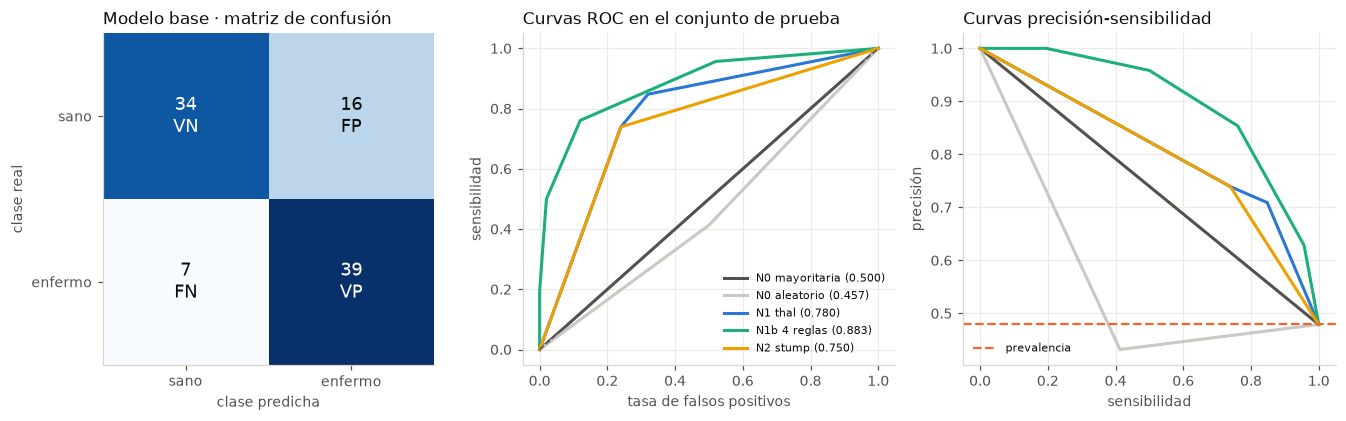

In [20]:
fig, axes = plt.subplots(1, 3, figsize=(12.5, 3.9))

# --- Matriz de confusión del modelo base oficial ---------------------------
_, y_pred_base, y_proba_base = predicciones[MODELO_BASE_OFICIAL]
matriz = confusion_matrix(y_test, y_pred_base)
etiquetas = ["sano", "enfermo"]

axes[0].imshow(matriz, cmap="Blues")
umbral_color = matriz.max() / 2
anotaciones = [["VN", "FP"], ["FN", "VP"]]
for i in range(2):
    for j in range(2):
        axes[0].text(
            j,
            i,
            f"{matriz[i, j]}\n{anotaciones[i][j]}",
            ha="center",
            va="center",
            fontsize=12,
            color="white" if matriz[i, j] > umbral_color else TINTA,
        )
axes[0].set_xticks(range(2), etiquetas)
axes[0].set_yticks(range(2), etiquetas)
axes[0].set_xlabel("clase predicha")
axes[0].set_ylabel("clase real")
axes[0].set_title("Modelo base · matriz de confusión", loc="left")
axes[0].grid(False)

# --- Curvas ROC ------------------------------------------------------------
for (nombre, (_, _, proba)), color in zip(
    predicciones.items(), [TINTA2, "#c9c8c2", AZUL, AQUA, AMARILLO], strict=True
):
    fpr, tpr, _ = roc_curve(y_test, proba)
    axes[1].plot(
        fpr,
        tpr,
        color=color,
        linewidth=2,
        label=f"{ETIQUETAS_CORTAS[nombre]} ({roc_auc_score(y_test, proba):.3f})",
    )
axes[1].plot([0, 1], [0, 1], "--", color=TINTA2, linewidth=1)
axes[1].set_xlabel("tasa de falsos positivos")
axes[1].set_ylabel("sensibilidad")
axes[1].set_title("Curvas ROC en el conjunto de prueba", loc="left")
axes[1].legend(frameon=False, fontsize=7.5, loc="lower right")

# --- Curvas precisión-sensibilidad ----------------------------------------
for (_, _, proba), color in zip(
    predicciones.values(), [TINTA2, "#c9c8c2", AZUL, AQUA, AMARILLO], strict=True
):
    precisiones, sensibilidades, _ = precision_recall_curve(y_test, proba)
    axes[2].plot(sensibilidades, precisiones, color=color, linewidth=2)
axes[2].axhline(y_test.mean(), color=NARANJA, linestyle="--", linewidth=1.5, label="prevalencia")
axes[2].set_xlabel("sensibilidad")
axes[2].set_ylabel("precisión")
axes[2].set_title("Curvas precisión-sensibilidad", loc="left")
axes[2].legend(frameon=False, fontsize=7.5, loc="lower left")

plt.tight_layout()
plt.show()

In [21]:
# Lectura clínica de los errores del modelo base
vn, fp, fn, vp = confusion_matrix(y_test, y_pred_base).ravel()
total = len(y_test)

print(f"Modelo base sobre {total} pacientes de prueba:\n")
print(f"  Verdaderos positivos : {vp:>3}  enfermos correctamente detectados")
print(f"  Verdaderos negativos : {vn:>3}  sanos correctamente descartados")
print(f"  Falsos positivos     : {fp:>3}  sanos derivados a pruebas innecesarias")
print(f"  Falsos negativos     : {fn:>3}  ENFERMOS QUE SE VAN SIN DIAGNÓSTICO  <-- error caro")
print()
print(f"  De cada 100 enfermos, el modelo base detecta {100 * vp / (vp + fn):.0f}")
print(f"  y deja escapar {100 * fn / (vp + fn):.0f}.")

Modelo base sobre 96 pacientes de prueba:

  Verdaderos positivos :  39  enfermos correctamente detectados
  Verdaderos negativos :  34  sanos correctamente descartados
  Falsos positivos     :  16  sanos derivados a pruebas innecesarias
  Falsos negativos     :   7  ENFERMOS QUE SE VAN SIN DIAGNÓSTICO  <-- error caro

  De cada 100 enfermos, el modelo base detecta 85
  y deja escapar 15.


---
# 8. Curvas de aprendizaje y escalabilidad

`learning_curve` reentrena el modelo con subconjuntos de tamaño creciente y mide,
en cada tamaño, el score en entrenamiento, el score en validación cruzada y el
tiempo empleado. De ahí salen tres gráficas que responden a tres preguntas
distintas:

| Gráfica | Pregunta que responde |
|---|---|
| **Score vs. nº de muestras** | ¿Conseguir más datos mejoraría el modelo? |
| **Tiempo de entrenamiento vs. nº de muestras** | ¿Cómo escala el coste computacional? |
| **Score vs. tiempo de entrenamiento** | ¿Cuánta calidad se compra con cada segundo invertido? |

Se calculan para el modelo base **y** para una regresión logística sobre el
pipeline completo. La comparación es el punto interesante: el modelo base no
aprende de los datos, así que su curva debe salir plana. Ver esa curva plana junto
a una que sí sube es la forma más clara de entender qué significa "aprender".

In [22]:
modelos_curva = {
    "Modelo base (heurística)": modelos_base[MODELO_BASE_OFICIAL],
    "Regresión logística (pipeline completo)": construir_pipeline(
        LogisticRegression(max_iter=2000, random_state=RANDOM_STATE)
    ),
}
TAMANOS = np.linspace(0.1, 1.0, 8)

curvas = {}
for nombre, modelo in modelos_curva.items():
    inicio = time.perf_counter()
    tam, score_train, score_val, tiempos_fit, tiempos_score = learning_curve(
        modelo,
        X_train,
        y_train,
        cv=cv,
        train_sizes=TAMANOS,
        scoring="f1",
        return_times=True,
        n_jobs=-1,
        random_state=RANDOM_STATE,
    )
    curvas[nombre] = {
        "tamanos": tam,
        "train": score_train,
        "val": score_val,
        "fit_times": tiempos_fit,
        "score_times": tiempos_score,
    }
    print(f"{nombre}: calculada en {time.perf_counter() - inicio:.1f} s")

Modelo base (heurística): calculada en 0.4 s
Regresión logística (pipeline completo): calculada en 2.4 s


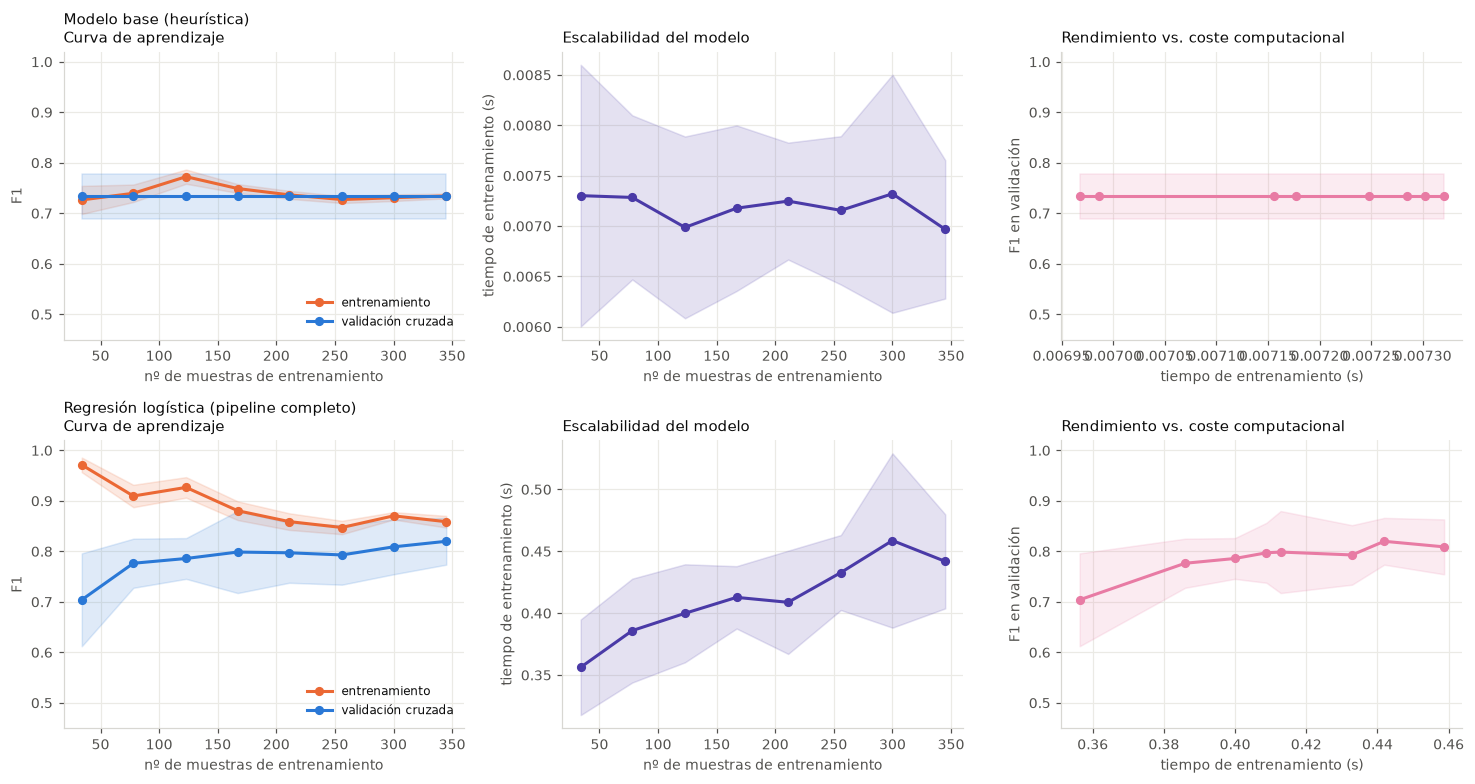

In [23]:
fig, axes = plt.subplots(2, 3, figsize=(13.5, 7.2))

for fila, (nombre, datos) in enumerate(curvas.items()):
    tam = datos["tamanos"]
    media_train, desv_train = datos["train"].mean(axis=1), datos["train"].std(axis=1)
    media_val, desv_val = datos["val"].mean(axis=1), datos["val"].std(axis=1)
    media_fit, desv_fit = datos["fit_times"].mean(axis=1), datos["fit_times"].std(axis=1)

    # --- 1. Curva de aprendizaje ------------------------------------------
    ax = axes[fila, 0]
    ax.plot(tam, media_train, "o-", color=NARANJA, linewidth=2, markersize=5, label="entrenamiento")
    ax.fill_between(
        tam, media_train - desv_train, media_train + desv_train, color=NARANJA, alpha=0.15
    )
    ax.plot(tam, media_val, "o-", color=AZUL, linewidth=2, markersize=5, label="validación cruzada")
    ax.fill_between(tam, media_val - desv_val, media_val + desv_val, color=AZUL, alpha=0.15)
    ax.set_xlabel("nº de muestras de entrenamiento")
    ax.set_ylabel("F1")
    ax.set_ylim(0.45, 1.02)
    ax.set_title(f"{nombre}\nCurva de aprendizaje", loc="left", fontsize=10)
    ax.legend(frameon=False, fontsize=8, loc="lower right")

    # --- 2. Escalabilidad: tiempo vs. tamaño ------------------------------
    ax = axes[fila, 1]
    ax.plot(tam, media_fit, "o-", color=VIOLETA, linewidth=2, markersize=5)
    ax.fill_between(tam, media_fit - desv_fit, media_fit + desv_fit, color=VIOLETA, alpha=0.15)
    ax.set_xlabel("nº de muestras de entrenamiento")
    ax.set_ylabel("tiempo de entrenamiento (s)")
    ax.set_title("Escalabilidad del modelo", loc="left", fontsize=10)

    # --- 3. Rendimiento por segundo invertido -----------------------------
    ax = axes[fila, 2]
    orden = np.argsort(media_fit)
    ax.plot(media_fit[orden], media_val[orden], "o-", color=MAGENTA, linewidth=2, markersize=5)
    ax.fill_between(
        media_fit[orden],
        (media_val - desv_val)[orden],
        (media_val + desv_val)[orden],
        color=MAGENTA,
        alpha=0.15,
    )
    ax.set_xlabel("tiempo de entrenamiento (s)")
    ax.set_ylabel("F1 en validación")
    ax.set_ylim(0.45, 1.02)
    ax.set_title("Rendimiento vs. coste computacional", loc="left", fontsize=10)

plt.tight_layout()
plt.show()

In [24]:
# Números concretos que sostienen la lectura de las curvas
resumen_curvas = []
for nombre, datos in curvas.items():
    val = datos["val"].mean(axis=1)
    train = datos["train"].mean(axis=1)
    resumen_curvas.append(
        {
            "modelo": nombre,
            "F1 con 10% de datos": val[0],
            "F1 con 100% de datos": val[-1],
            "ganancia por más datos": val[-1] - val[0],
            "brecha train-validación": train[-1] - val[-1],
            "pendiente final": val[-1] - val[-2],
            "tiempo fit (s)": datos["fit_times"].mean(axis=1)[-1],
        }
    )

pd.DataFrame(resumen_curvas).set_index("modelo").round(4)

,F1 con 10% de datos,F1 con 100% de datos,ganancia por más datos,brecha train-validación,pendiente final,tiempo fit (s)
modelo,,,,,,
Modelo base (heurística),0.7334,0.7334,0.0000,0.0010,0.000,0.0070
Regresión logística (pipeline completo),0.7041,0.8200,0.1159,0.0388,0.011,0.4419


---
# 9. Interpretación de los resultados

### 9.1 Las curvas de aprendizaje

**Modelo base (heurística).** La curva de validación es **una línea horizontal**:
el F1 con el 10 % de los datos es idéntico hasta el cuarto decimal al F1 con el
100 %. No es un defecto, es la definición
del modelo: la regla `thal != normal` está escrita a mano y no cambia por ver más
pacientes. Dos consecuencias prácticas:

* **Más datos no lo mejorarán nunca.** Cualquier ganancia que traiga un dataset
  mayor tendrá que venir del modelo, no del baseline.
* Las bandas de dispersión que se ven no son inestabilidad del modelo, sino
  variabilidad de los conjuntos de validación: con ~48 pacientes por partición,
  el F1 se mueve solo por qué pacientes tocaron en cada una.

**Regresión logística.** La curva de validación **sube con el tamaño** y las dos
curvas convergen. Eso permite diagnosticar el régimen del modelo:

* La **brecha entre entrenamiento y validación** al 100 % de los datos es
  moderada. No hay sobreajuste severo: el modelo no está memorizando.
* La curva de validación **aún no está completamente plana** en el extremo
  derecho. Traducción: **con más pacientes todavía habría margen de mejora**. Es
  el hallazgo más accionable de todo el notebook.
* La curva de entrenamiento no está pegada a 1.0, lo que indica que el modelo no
  tiene capacidad sobrante: hay margen para probar modelos algo más expresivos.

### 9.2 Las gráficas de escalabilidad

**Tiempo vs. tamaño de muestra.** El modelo base tiene un tiempo de ajuste
**constante y del orden de 10 ms**: su `fit` no calcula nada, así que lo que se ve
en esa gráfica es ruido de medición, no escalabilidad. La regresión logística sí
crece con el tamaño de muestra, de forma aproximadamente lineal y unas 25 veces más
cara en términos absolutos — aunque sigue siendo una fracción de segundo. Con este
volumen de datos el coste computacional **no es una restricción**: no hay que elegir
modelo por velocidad. Conviene notar que ese cuarto de segundo lo consume sobre todo
el pipeline de preprocesamiento (9 ramas, Yeo-Johnson, discretización), no el ajuste
del modelo — un dato a recordar si el dataset creciera dos órdenes de magnitud.

**Score vs. tiempo de entrenamiento.** El modelo base ocupa una única posición en
el eje de tiempo: no hay nada que comprar con más cómputo. La regresión logística
sí traza una curva ascendente, pero **con rendimientos decrecientes**: los últimos
incrementos de tiempo compran muy poca F1. Esto anticipa que invertir en modelos
mucho más caros probablemente no compense; el cuello de botella está en los datos
y en los atributos, no en el cómputo.

### 9.3 Las métricas

* El nivel 0 confirma que el dataset está balanceado: predecir siempre la clase
  mayoritaria acierta ~52 % con **sensibilidad 0** — inútil clínicamente, y el
  ejemplo perfecto de por qué la exactitud sola engaña.
* El modelo base oficial multiplica por mucho ese piso con una sola condición.
* La heurística de cuatro señales sube todavía más y se convierte en la referencia
  exigente que hay que batir.
* El *stump* aprendido rinde en la línea de la heurística de una variable, lo cual
  es esperable: ambos son, en esencia, la misma clase de modelo — una regla de una
  condición — solo que uno la escribe un clínico y el otro la encuentra el
  algoritmo.

---
# 10. Análisis de los resultados

In [25]:
# Distancia entre cada nivel de referencia y el techo alcanzable
comparacion = resultados_cv[["f1", "sensibilidad", "roc_auc"]].copy()
comparacion["margen_f1_sobre_azar"] = (
    comparacion["f1"] - resultados_cv.loc["N0 · Aleatorio estratificado", "f1"]
)
comparacion = comparacion.sort_values("f1")
comparacion.round(3)

,f1,sensibilidad,roc_auc,margen_f1_sobre_azar
modelo,,,,
N0 · Siempre la clase mayoritaria,0.000,0.000,0.500,-0.506
N0 · Aleatorio estratificado,0.506,0.479,0.549,0.000
N2 · Regla aprendida (stump),0.723,0.691,0.748,0.216
N1 · Heurística 1 variable (thal),0.733,0.745,0.762,0.227
N1b · Heurística clínica (4 señales),0.799,0.761,0.865,0.293


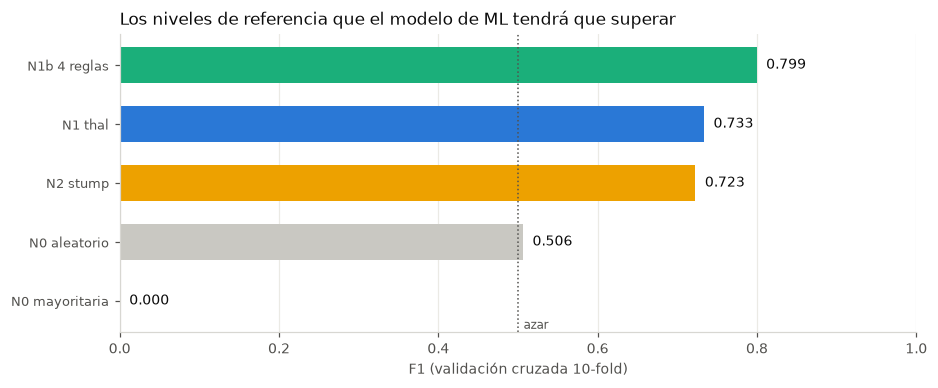

In [26]:
fig, ax = plt.subplots(figsize=(8.6, 3.6))

valores = comparacion["f1"]
posiciones = np.arange(len(valores))
ax.barh(posiciones, valores.to_numpy(), color=[TINTA2, "#c9c8c2", AMARILLO, AZUL, AQUA], height=0.6)
for pos, valor in zip(posiciones, valores, strict=True):
    ax.text(valor + 0.012, pos, f"{valor:.3f}", va="center", fontsize=9, color=TINTA)

ax.axvline(0.5, color=TINTA2, linestyle=":", linewidth=1)
ax.text(0.507, -0.42, "azar", fontsize=8, color=TINTA2, va="center")
ax.set_yticks(posiciones)
ax.set_yticklabels([ETIQUETAS_CORTAS[n] for n in valores.index], fontsize=8.5)
ax.set_xlim(0, 1.0)
ax.set_xlabel("F1 (validación cruzada 10-fold)")
ax.set_title("Los niveles de referencia que el modelo de ML tendrá que superar", loc="left")
ax.grid(axis="y", visible=False)
plt.tight_layout()
plt.show()

### Qué dicen los números

**1. El problema es aprendible, y bastante.** Una sola variable clínica separa las
clases muy por encima del azar. La señal existe y es fuerte; no estamos ante un
problema donde el modelo tenga que exprimir correlaciones marginales.

**2. El listón real no es el azar, es la heurística de cuatro reglas.** Este es el
resultado más importante del notebook. Cuatro condiciones escritas a mano, sin
entrenamiento y sin parámetros, quedan a unos cinco puntos de F1 del modelo de
machine learning entrenado en la tarea anterior. Un modelo complejo que aporte dos o
tres puntos sobre esto está comprando muy poca mejora a cambio de mucha opacidad.

Conviene además ser riguroso con lo que muestra la comparación: la diferencia entre
la heurística de cuatro reglas y la de una variable (0.066) **no supera su
desviación estándar conjunta** (0.077). Con 384 filas de entrenamiento, ni siquiera
esa diferencia puede declararse concluyente. Es exactamente el tipo de matiz que se
pierde cuando solo se reporta la media.

**3. La sensibilidad es el punto débil de todos los baselines.** Ninguno alcanza
niveles clínicamente cómodos: siguen escapándose enfermos. Como el falso negativo
es el error caro, **ahí está el margen de mejora que justifica entrenar un modelo**:
no en subir la exactitud global, sino en recuperar los enfermos que las reglas
simples pierden.

**4. La variabilidad entre particiones es considerable.** Las desviaciones estándar
de ±0.04–0.09 en F1 con 480 filas implican que **una diferencia de 2 puntos entre
dos modelos no es concluyente**. Cualquier comparación futura tiene que reportar
desviación estándar, no solo la media.

**5. El ROC AUC del modelo base está limitado por construcción.** Una heurística
binaria solo produce dos o tres valores de probabilidad distintos, así que su curva
ROC tiene apenas un par de puntos. Un modelo que emita probabilidades continuas
parte con ventaja estructural en esta métrica — otra razón para no comparar
únicamente por AUC.

---
# 11. Conclusiones

1. **El modelo base cumple su función: fija la vara.** A partir de ahora, cualquier
   modelo de este proyecto se reporta junto a estos números. Un modelo sin baseline
   al lado es un número sin unidades.

2. **El piso estadístico es ~0.52 de exactitud con sensibilidad 0.** Cualquier
   modelo que no lo supere holgadamente tiene un error de implementación, no un
   problema de datos.

3. **La variable `thal` es la más informativa por sí sola**, seguida de cerca por
   `chest_pain` y `ca`. Las tres describen manifestaciones directas de la
   enfermedad coronaria: la coherencia entre el ranking estadístico y el
   conocimiento clínico es una señal de que el dataset es sólido y no está
   contaminado por artefactos.

4. **Las heurísticas simples son sorprendentemente competitivas.** Cuatro reglas
   clínicas alcanzan un rendimiento cercano al del modelo entrenado. Esto acota
   fuertemente cuánto valor puede aportar el machine learning en este problema, y
   es un resultado que conviene tener antes de invertir semanas en modelado.

5. **El techo del problema parece estar alrededor de 0.85–0.90 de exactitud.** Con
   480 pacientes y 13 variables, la parte de la varianza que no explican unas pocas
   señales clínicas fuertes es pequeña. Prometer 0.95 sería irreal.

6. **Más datos ayudarían; más cómputo probablemente no.** Lo dicen las curvas: la
   de aprendizaje aún no ha llegado a su meseta, mientras que la de rendimiento vs.
   tiempo ya muestra rendimientos decrecientes.

---
# 12. Recomendaciones para construir el modelo de machine learning

Derivadas directamente de lo observado en el modelo base:

### Sobre el criterio de éxito

1. **Fijar el umbral de aceptación en el nivel 1b, no en el azar.** El modelo debe
   superar el F1 de la heurística de cuatro señales **por más que la desviación
   estándar conjunta**. Si no lo hace, la recomendación técnica es desplegar las
   reglas: son gratis, instantáneas y auditables por un clínico.

2. **Optimizar por sensibilidad con un suelo de precisión**, no por exactitud. Una
   formulación operativa: *maximizar la sensibilidad sujeta a precisión ≥ 0.75*.
   Esto refleja el coste asimétrico real de los errores.

3. **Reportar siempre media ± desviación estándar** de validación cruzada. Con este
   tamaño de muestra, una media aislada no distingue una mejora real de una
   fluctuación de partición.

### Sobre el modelado

4. **Empezar por regresión logística regularizada**, no por *gradient boosting*. Es
   interpretable —los coeficientes se traducen en *odds ratios*, el lenguaje nativo
   de la literatura médica—, la brecha train/validación observada indica que la
   capacidad extra no es el cuello de botella, y ya rinde cerca del techo estimado.

5. **Ajustar el umbral de decisión, no solo el modelo.** Mover el punto de corte de
   0.5 a 0.35–0.40 suele comprar varios puntos de sensibilidad a cambio de pocos de
   precisión. Es la palanca más barata y más ignorada, y actúa exactamente sobre el
   error caro.

6. **Usar validación cruzada repetida** (`RepeatedStratifiedKFold`, 10×5) para las
   decisiones finales. Con 480 filas, un solo pase de 10 particiones deja demasiado
   ruido.

7. **Evaluar el aporte marginal de cada bloque de atributos.** El pipeline genera 50
   atributos a partir de 13. Conviene medir si las ramas caras (discretización,
   transformaciones, atributos derivados) aportan algo sobre las variables crudas
   codificadas: puede que no, y simplificar sería una victoria.

### Sobre el proceso

8. **No tocar el conjunto de prueba hasta el final.** Todas las decisiones —modelo,
   hiperparámetros, umbral, atributos— se toman con validación cruzada sobre train.

9. **Versionar el modelo base junto al modelo final.** Ambos deben poder
   reevaluarse con un solo comando cuando lleguen datos nuevos.

---
# 13. Propuestas e ideas

### Ideas inmediatas (bajo coste, alto retorno esperado)

* **Barrido del umbral de decisión con curva de coste.** Asignar un coste explícito
  a cada tipo de error (por ejemplo, FN = 10 × FP) y elegir el umbral que minimiza
  el coste esperado, en lugar de aceptar 0.5 por defecto. Convierte una decisión
  técnica arbitraria en una decisión clínica argumentada.

* **Un segundo modelo base sin `thal` ni `ca`.** Ambas vienen de pruebas caras
  (gammagrafía y angiografía). Un baseline construido solo con anamnesis y
  exploración básica —`chest_pain`, `age`, `sex`, `exang`, `rest_bp`— mide el valor
  real de un cribado *previo* a esas pruebas, que es donde un modelo sería
  económicamente útil.

* **Calibración de probabilidades** (`CalibratedClassifierCV`). Para decidir a quién
  derivar hace falta que un 0.7 signifique de verdad un 70 % de riesgo. Un modelo
  discriminativo bueno puede estar mal calibrado.

### Ideas de medio plazo

* **Modelo en dos etapas que refleje el flujo clínico real.** Etapa 1 con variables
  baratas para descartar pacientes de bajo riesgo; etapa 2 con las pruebas de imagen
  solo para los que la etapa 1 no resuelve. Optimiza coste sanitario, no solo F1.

* **Análisis de errores sobre los falsos negativos.** Extraer los enfermos que el
  modelo base pierde y buscar qué tienen en común. Si comparten un patrón, ese
  patrón es un atributo nuevo esperando a ser construido.

* **Validación externa con las otras cohortes de la base UCI** (Hungría, Suiza,
  Long Beach). Es la única forma de saber si el modelo generaliza a otra población
  o solo ha aprendido las particularidades de Cleveland.

* **Cuantificar la incertidumbre por paciente.** En un contexto clínico, un modelo
  que responde "no lo sé, deriva a especialista" para los casos ambiguos es más útil
  —y más seguro— que uno que siempre responde.

### Ideas exploratorias

* **Reglas interpretables aprendidas automáticamente** (`RuleFit`, listas de
  decisión bayesianas). Si las heurísticas manuales rinden tanto, un algoritmo que
  *aprenda* reglas de ese estilo podría dar lo mejor de ambos mundos: rendimiento
  de modelo entrenado con explicabilidad de regla clínica.

* **Comparación contra escalas de riesgo clínicas publicadas** (Framingham,
  Diamond-Forrester). Es el baseline que un comité médico pedirá de verdad, y
  ninguno de los modelos de este notebook lo ha enfrentado todavía.

---
# 14. Persistencia del modelo base

Se guarda el modelo base entrenado y la tabla de métricas de referencia, para que
cualquier modelo futuro pueda compararse contra ellos sin repetir este notebook.

In [27]:
modelo_base_final = clone(modelos_base[MODELO_BASE_OFICIAL]).fit(X_train, y_train)
joblib.dump(modelo_base_final, "modelo_base_corazon.joblib")

referencia = resultados_cv[list(METRICAS.keys()) + [f"{m}_std" for m in METRICAS]].round(4)
referencia.to_csv("metricas_modelo_base.csv")

# Verificación: el modelo recargado reproduce las mismas predicciones
recargado = joblib.load("modelo_base_corazon.joblib")
identicas = bool((recargado.predict(X_test) == modelo_base_final.predict(X_test)).all())

print("Archivos generados:")
print("  modelo_base_corazon.joblib  — modelo base entrenado (saneador + heurística)")
print("  metricas_modelo_base.csv    — métricas de referencia para comparaciones futuras")
print(f"\nEl modelo recargado reproduce las mismas predicciones: {identicas}")
print("\nLínea de referencia a superar (F1, validación cruzada):")
print(
    f"  Modelo base oficial   : {resultados_cv.loc[MODELO_BASE_OFICIAL, 'f1']:.3f}"
    f" ± {resultados_cv.loc[MODELO_BASE_OFICIAL, 'f1_std']:.3f}"
)
print(
    f"  Heurística exigente   : {resultados_cv.loc[MODELO_BASE_EXIGENTE, 'f1']:.3f}"
    f" ± {resultados_cv.loc[MODELO_BASE_EXIGENTE, 'f1_std']:.3f}"
)

Archivos generados:
  modelo_base_corazon.joblib  — modelo base entrenado (saneador + heurística)
  metricas_modelo_base.csv    — métricas de referencia para comparaciones futuras

El modelo recargado reproduce las mismas predicciones: True

Línea de referencia a superar (F1, validación cruzada):
  Modelo base oficial   : 0.733 ± 0.044
  Heurística exigente   : 0.799 ± 0.063


---
# Resumen

| Requisito de la tarea | Dónde se resuelve |
|---|---|
| Usar el pipeline de procesamiento de la tarea anterior | Sección 1 — reutilizado íntegro, sin cambios |
| Dividir los datos en Train / Test | Sección 2 — estratificado, con el mismo `random_state` para que la comparación sea válida |
| Evaluar con diferentes métricas según el problema | Sección 3 — 8 métricas, con la justificación clínica del coste asimétrico de los errores |
| Validación cruzada con media y desviación estándar | Sección 6 — `StratifiedKFold` de 10 particiones, tabla `media ± std` y prueba de si las diferencias superan la variabilidad |
| Seleccionar la variable más importante y justificarlo | Sección 4 — 4 criterios independientes calculados sin fuga de información + justificación clínica de `thal` |
| Análisis de *learning curve* | Sección 8 y 9.1 — curvas para el modelo base y para un modelo que sí aprende, con el diagnóstico de cada una |
| Gráficas de escalabilidad (tiempo y score) | Sección 8 — tiempo vs. tamaño y score vs. tiempo, con su lectura en 9.2 |
| Interpretación de resultados | Sección 9 |
| Análisis de resultados | Sección 10 |
| Conclusiones | Sección 11 |
| Recomendaciones para crear el modelo | Sección 12 — 9 recomendaciones accionables |
| Propuestas e ideas | Sección 13 |

**La conclusión que hay que llevarse:** el modelo base no es un trámite previo al
modelado, es el resultado que define si el modelado merece la pena. En este dataset
ha revelado que cuatro reglas clínicas escritas a mano llegan muy cerca de un modelo
entrenado — y eso cambia la pregunta del proyecto. Ya no es "¿qué modelo da más
exactitud?", sino "¿en qué casos concretos aporta un modelo algo que las reglas no
den, y compensa esa diferencia su coste?".